Preparacion del entorno que me permite revisar el archivo en cualquier ruta

In [11]:

import pandas as pd
import importlib
import sys #busca la carpeta segun es sistema operativo
import os
sys.path.append(os.path.abspath(".."))

#lectura de la data sin limpiar(csv)
ruta = "../data/urgencias_noprocesados_grupo01.csv"
df = pd.read_csv(ruta, encoding="utf-8") #lee mi csv codificandola a la configuracion regional


Datos Sin limpiar


In [12]:
#exploracion de la data sin limpiar
print(df.head()) #muestra las primeras filas del dataframe,los nombres de las columnas y los tipos de datos

   EstablecimientoCodigo                     EstablecimientoGlosa  \
0                 110901  Hospital Regional de Arica Dr. Juan Noe   
1                 110901  Hospital Regional de Arica Dr. Juan Noe   
2                 110901  Hospital Regional de Arica Dr. Juan Noe   
3                 110901  Hospital Regional de Arica Dr. Juan Noe   
4                 110901  Hospital Regional de Arica Dr. Juan Noe   

   RegionCodigo         RegionGlosa  ComunaCodigo ComunaGlosa  \
0            15  Arica y Parinacota         15101       Arica   
1            15  Arica y Parinacota         15101       Arica   
2            15  Arica y Parinacota         15101       Arica   
3            15  Arica y Parinacota         15101       Arica   
4            15  Arica y Parinacota         15101       Arica   

   ServicioSaludCodigo       ServicioSaludGlosa TipoEstablecimiento  \
0                    1  Servicio de Salud Arica            Hospital   
1                    1  Servicio de Salud Arica     

In [13]:
#muestra las columnas del dataframe, es decir, los nombres de las variables

print(df.columns)

Index(['EstablecimientoCodigo', 'EstablecimientoGlosa', 'RegionCodigo',
       'RegionGlosa', 'ComunaCodigo', 'ComunaGlosa', 'ServicioSaludCodigo',
       'ServicioSaludGlosa', 'TipoEstablecimiento',
       'DependenciaAdministrativa', 'NivelAtencion', 'TipoUrgencia', 'Latitud',
       'Longitud', 'NivelComplejidad', 'Anio', 'SemanaEstadistica',
       'OrdenCausa', 'Causa', 'NumTotal', 'NumMenor1Anio', 'Num1a4Anios',
       'Num5a14Anios', 'Num15a64Anios', 'Num65oMas', 'FechaAtencionTexto',
       'SexoPaciente', 'PrioridadTriage', 'CostoAtencionCLP'],
      dtype='str')


In [14]:
#muestra los tipos de datos de cada columna
print(df.dtypes)

EstablecimientoCodigo          int64
EstablecimientoGlosa             str
RegionCodigo                   int64
RegionGlosa                      str
ComunaCodigo                   int64
ComunaGlosa                      str
ServicioSaludCodigo            int64
ServicioSaludGlosa               str
TipoEstablecimiento              str
DependenciaAdministrativa        str
NivelAtencion                    str
TipoUrgencia                     str
Latitud                      float64
Longitud                     float64
NivelComplejidad                 str
Anio                           int64
SemanaEstadistica              int64
OrdenCausa                     int64
Causa                            str
NumTotal                       int64
NumMenor1Anio                  int64
Num1a4Anios                    int64
Num5a14Anios                   int64
Num15a64Anios                  int64
Num65oMas                      int64
FechaAtencionTexto               str
SexoPaciente                     str
P

In [15]:
#contar valores nulos x columna
df.isnull().sum()

EstablecimientoCodigo         0
EstablecimientoGlosa          0
RegionCodigo                  0
RegionGlosa                   0
ComunaCodigo                  0
ComunaGlosa                   0
ServicioSaludCodigo           0
ServicioSaludGlosa            0
TipoEstablecimiento           0
DependenciaAdministrativa    26
NivelAtencion                 0
TipoUrgencia                 16
Latitud                      19
Longitud                     11
NivelComplejidad             24
Anio                          0
SemanaEstadistica             0
OrdenCausa                    0
Causa                         0
NumTotal                      0
NumMenor1Anio                 0
Num1a4Anios                   0
Num5a14Anios                  0
Num15a64Anios                 0
Num65oMas                     0
FechaAtencionTexto           18
SexoPaciente                 20
PrioridadTriage              18
CostoAtencionCLP             18
dtype: int64

In [16]:
#valores duplicados
df.duplicated().sum()

np.int64(37)

In [17]:
# Método IQR Percentiles (rango intercuartilico)

q1 = df['NumTotal'].quantile(0.25)
q3 = df['NumTotal'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5*iqr
limite_superior = q3 + 1.5*iqr

outliers = df[(df['NumTotal'] < limite_inferior) | (df['NumTotal'] > limite_superior)]

outliers

,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,...,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas,FechaAtencionTexto,SexoPaciente,PrioridadTriage,CostoAtencionCLP
258,131622,SAPU Pudahuel Sur,13,Metropolitana,13126,Pudahuel,8,Servicio de Salud Metropolitano Occidente,Centro de Salud,Municipal,...,1238,8,12,18,51,22,27.02.23,M,C3,129829.0
630,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,331,30,32,39,131,99,2023/05/29,M,C4,136855.0
665,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,332,15,40,72,168,37,05.06.23,F,C3,99042.0
817,130215,Hospital Dr. Gustavo Fricke,5,Valparaiso,5109,Vina del Mar,5,Servicio de Salud Vina del Mar-Quillota,Hospital,Servicio de Salud,...,2287,16,24,63,145,34,2023/07/10,M,C2,58049.0
929,910333,Hospital Regional de Temuco,9,La Araucania,9101,Temuco,13,Servicio de Salud Araucania Sur,Hospital,Servicio de Salud,...,340,28,42,72,160,38,2023/07/31,M,C2,74797.0
966,130215,Hospital Dr. Gustavo Fricke,5,Valparaiso,5109,Vina del Mar,5,Servicio de Salud Vina del Mar-Quillota,Hospital,Servicio de Salud,...,337,27,27,52,142,89,14-08-2023,M,C4,82539.0
1739,910333,Hospital Regional de Temuco,9,La Araucania,9101,Temuco,13,Servicio de Salud Araucania Sur,Hospital,Servicio de Salud,...,2078,7,21,35,72,30,05-02-2024,F,C3,80635.0
2254,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,2577,3,8,18,81,112,10.06.24,M,C1,125520.0
2280,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,331,21,29,65,143,73,2024/06/17,M,C3,95214.0
2318,130215,Hospital Dr. Gustavo Fricke,5,Valparaiso,5109,Vina del Mar,5,Servicio de Salud Vina del Mar-Quillota,Hospital,Servicio de Salud,...,338,101,93,49,76,19,2024/06/24,F,C3,70227.0


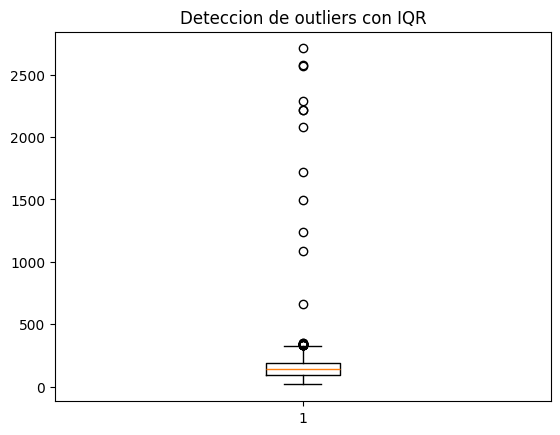

In [18]:
import matplotlib.pyplot as plt
plt.boxplot(df["NumTotal"].dropna())
plt.title("Deteccion de outliers con IQR")
plt.show()

In [30]:
# 1. Definimos las columnas 
cols_edad = ['NumMenor1Anio', 'Num1a4Anios', 'Num5a14Anios', 'Num15a64Anios', 'Num65oMas']
col_total = 'NumTotal'

# 2. Creamos una copia temporal para el análisis
df_analisis = df.copy()

# 3. Aseguramos que todo sea numérico para poder sumar
for col in cols_edad + [col_total]:
    df_analisis[col] = pd.to_numeric(df_analisis[col], errors='coerce').fillna(0)

# 4. Calculamos la suma real de las columnas de edad
df_analisis['Suma_Calculada'] = df_analisis[cols_edad].sum(axis=1)

# 5. Identificamos las filas donde NO coinciden
mask_error = df_analisis[col_total] != df_analisis['Suma_Calculada']
df_errores = df_analisis[mask_error]

# 6. Reporte Final
total_filas = len(df_analisis)
cant_errores = len(df_errores)
porcentaje = (cant_errores / total_filas) * 100

print(f"--- REPORTE DE COHERENCIA ---")
print(f"Total de registros: {total_filas}")
print(f"Registros con error: {cant_errores}")
print(f"Porcentaje de error: {porcentaje:.2f}%")
print("-" * 30)

if cant_errores > 0:
    print("Muestra de las primeras 10 filas que NO coinciden:")
    # Mostramos el Total original vs la Suma que calculamos nosotros
    columnas_vista = [col_total, 'Suma_Calculada'] + cols_edad
    print(df_errores[columnas_vista].head(10))
else:
    print("¡Excelente! El 100% de los totales coinciden con la suma de las edades.")

--- REPORTE DE COHERENCIA ---
Total de registros: 4742
Registros con error: 97
Porcentaje de error: 2.05%
------------------------------
Muestra de las primeras 10 filas que NO coinciden:
     NumTotal  Suma_Calculada  NumMenor1Anio  Num1a4Anios  Num5a14Anios  \
55         49             393              4          348             9   
177       170            1282              8           23          1162   
258      1238             111              8           12            18   
308       127            1366           1281           29            14   
318       171            1184             14           13          1034   
433       135             103              6           10            18   
438       160             938             15          797            24   
444       227            1444           1236           22            41   
448       146             765              5            4            15   
506       192             190             62           37     

In [81]:
df_original = pd.read_csv("../data/urgencias_noprocesados_grupo01.csv")

import src.limpieza as limpieza_module
import importlib
importlib.reload(limpieza_module)

df_limpio = limpieza_module.limpiar_datos(df_original)

df_limpio.to_csv('../outputs/limpio.csv', index=False)


Datos Limpios

In [67]:
#Visualizacion del dataframe limpio
ruta_limpio = "../outputs/limpio.csv"
df_limpio = pd.read_csv(ruta_limpio, encoding="utf-8")
df_limpio.head()

,establecimientocodigo,establecimientoglosa,regioncodigo,regionglosa,comunacodigo,comunaglosa,serviciosaludcodigo,serviciosaludglosa,tipoestablecimiento,dependenciaadministrativa,...,numtotal,nummenor1anio,num1a4anios,num5a14anios,num15a64anios,num65omas,fechaatenciontexto,sexopaciente,prioridadtriage,costoatencionclp
0,110901,hospital regional de arica dr. juan noe,15,arica y parinacota,15101,arica,1,servicio de salud arica,hospital,servicio de salud,...,201,19,21,27,87,47,2023-01-02,F,C4,68063.0
1,110901,hospital regional de arica dr. juan noe,15,arica y parinacota,15101,arica,1,servicio de salud arica,hospital,servicio de salud,...,193,14,25,30,106,18,2023-01-02,F,C3,66252.0
2,110901,hospital regional de arica dr. juan noe,15,arica y parinacota,15101,arica,1,servicio de salud arica,hospital,servicio de salud,...,94,18,19,23,28,6,2023-02-01,M,C2,101700.0
3,110901,hospital regional de arica dr. juan noe,15,arica y parinacota,15101,arica,1,servicio de salud arica,hospital,servicio de salud,...,74,3,11,17,35,8,2023-01-02,F,C1,96564.0
4,110901,hospital regional de arica dr. juan noe,15,arica y parinacota,15101,arica,1,servicio de salud arica,hospital,servicio de salud,...,132,5,5,3,61,58,2023-02-01,F,C2,114250.0


In [68]:
#Visualizacion de las columnas del dataframe limpio
df_limpio.columns

Index(['establecimientocodigo', 'establecimientoglosa', 'regioncodigo',
       'regionglosa', 'comunacodigo', 'comunaglosa', 'serviciosaludcodigo',
       'serviciosaludglosa', 'tipoestablecimiento',
       'dependenciaadministrativa', 'nivelatencion', 'tipourgencia', 'latitud',
       'longitud', 'nivelcomplejidad', 'anio', 'semanaestadistica',
       'ordencausa', 'causa', 'numtotal', 'nummenor1anio', 'num1a4anios',
       'num5a14anios', 'num15a64anios', 'num65omas', 'fechaatenciontexto',
       'sexopaciente', 'prioridadtriage', 'costoatencionclp'],
      dtype='str')

=== INFORME DE ANÁLISIS EXPLORATORIO (EDA) ===
Tamaño del dataset: 4592 filas y 29 columnas
--------------------------------------------------
--- VALIDACIÓN DE INTEGRIDAD DE DATOS ---
            Métrica  Resultado
   Filas Duplicadas          0
Valores Nulos (NaN)          0
 Total de Registros       4592
----------------------------------------

[0] VOLUMEN PROMEDIO DE PACIENTES POR GRUPO ETARIO


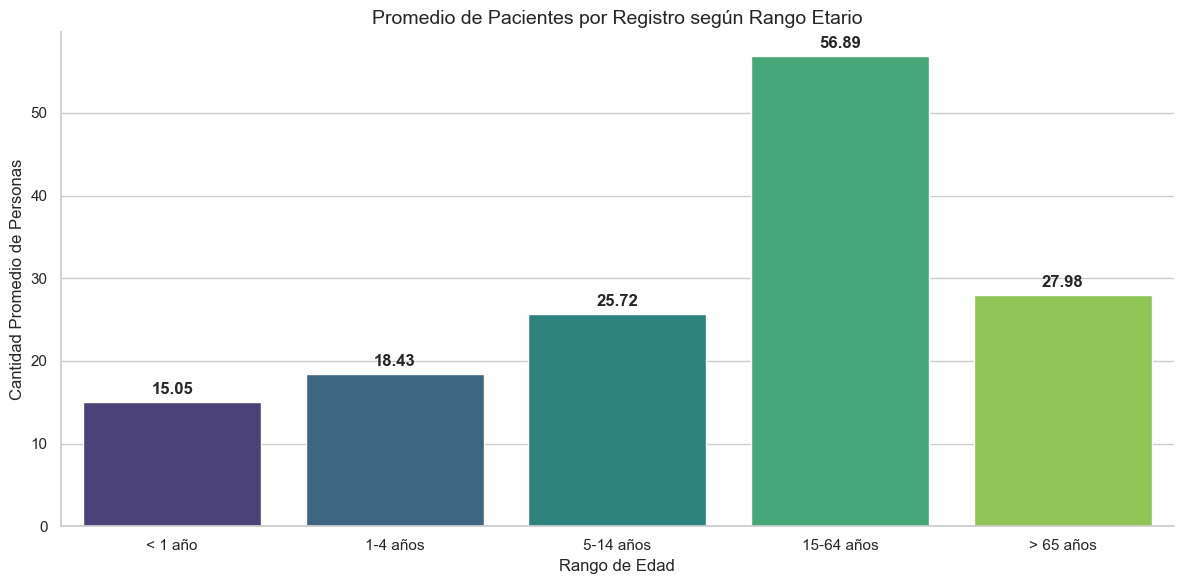

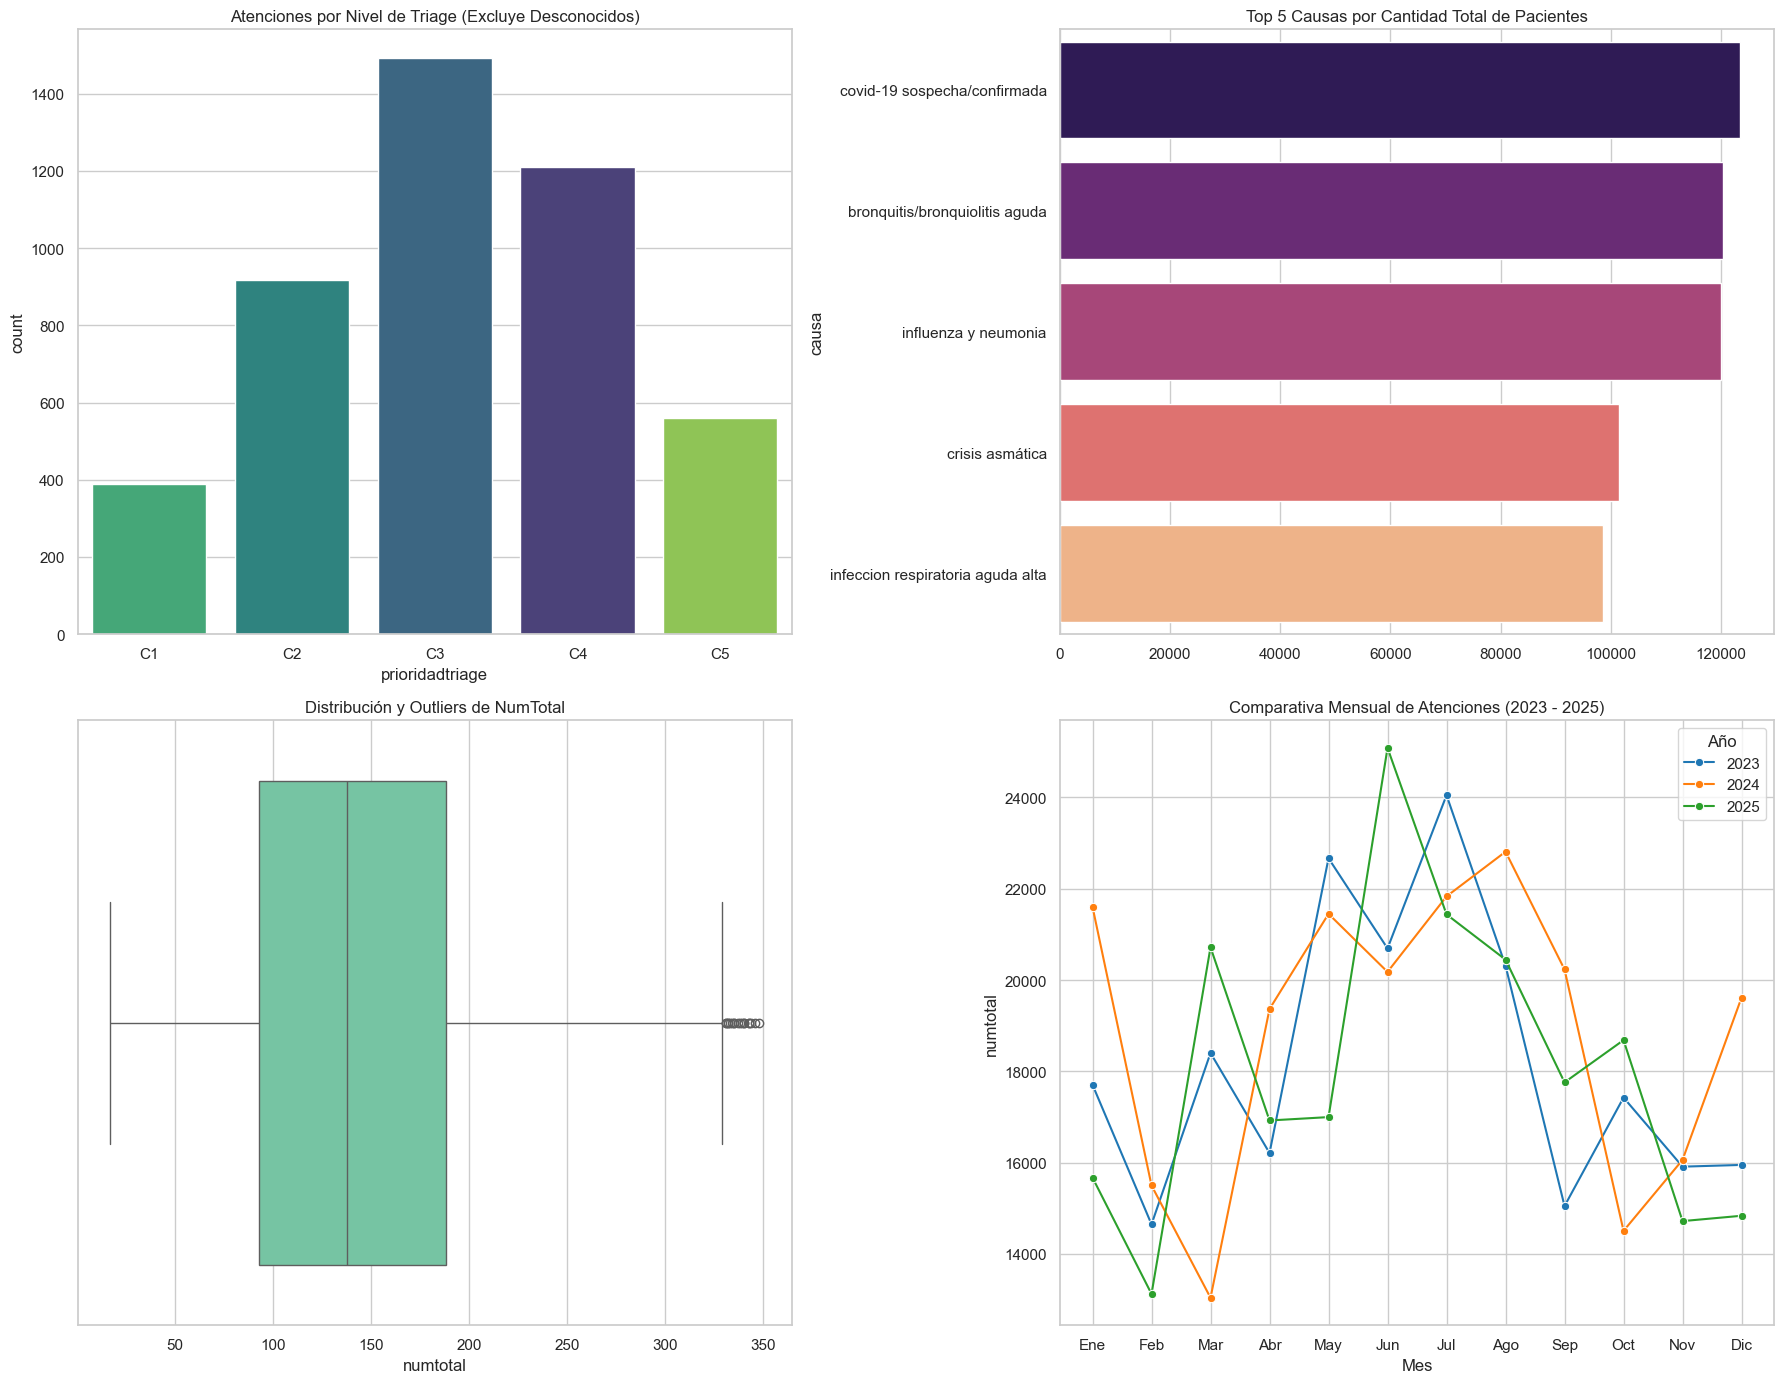


[4] CORRELACIÓN ENTRE RANGOS ETARIOS


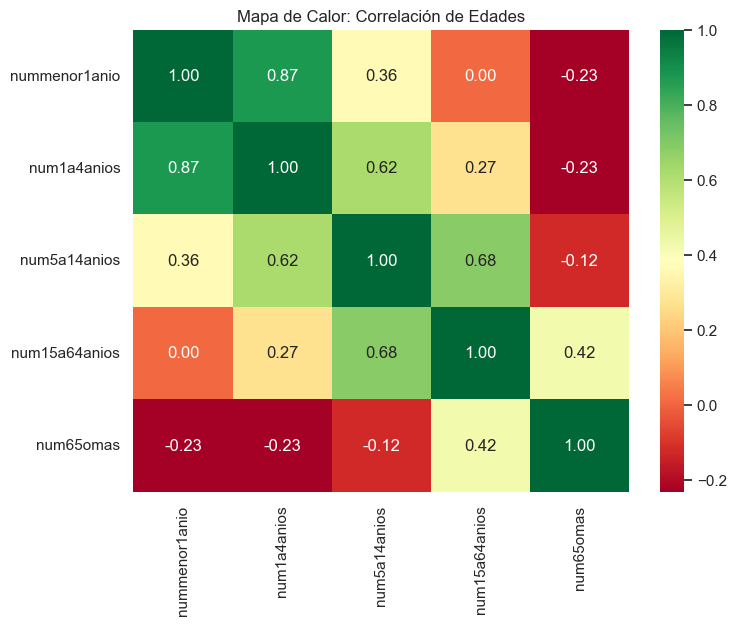


[5] ANALIZANDO RELACIÓN CAUSA VS RANGO DE EDAD...


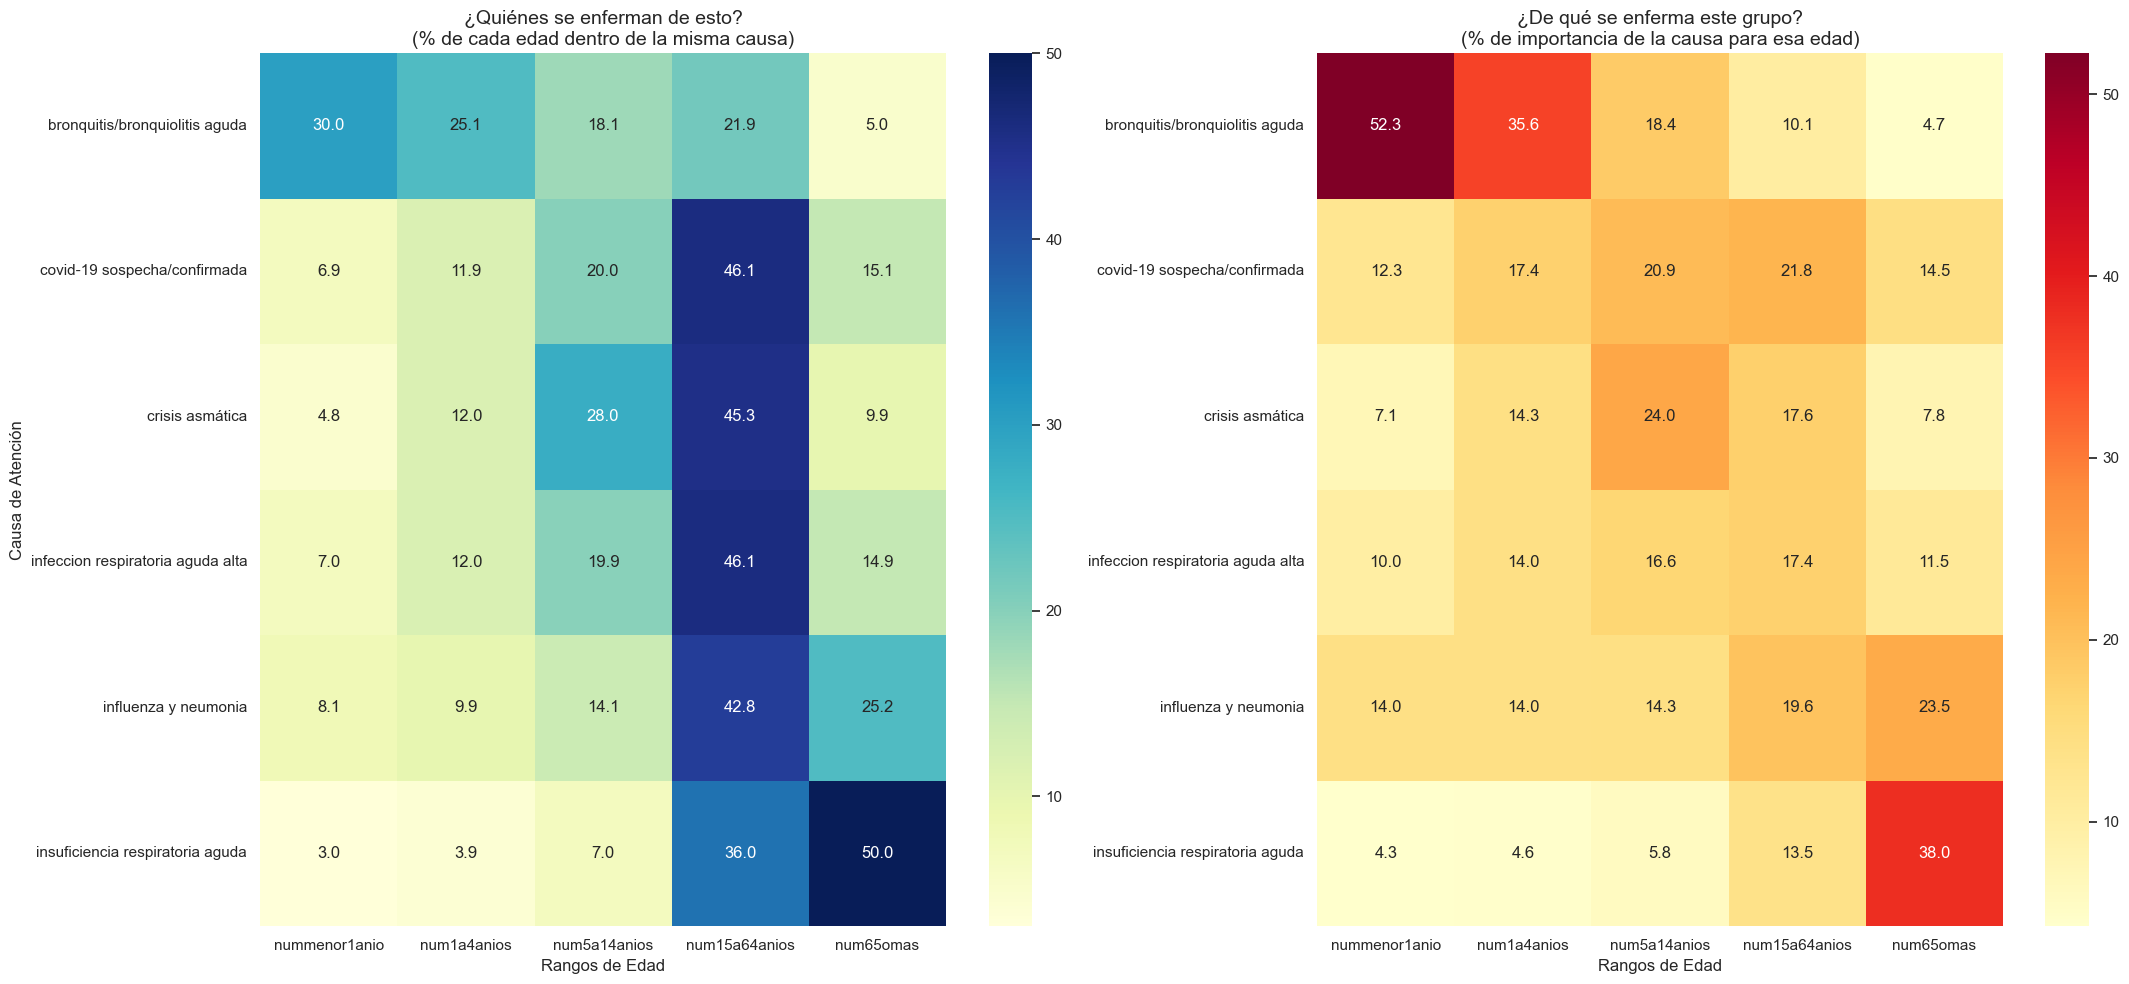


[6] ANALIZANDO ESTACIONALIDAD POR GRUPO DE EDAD...


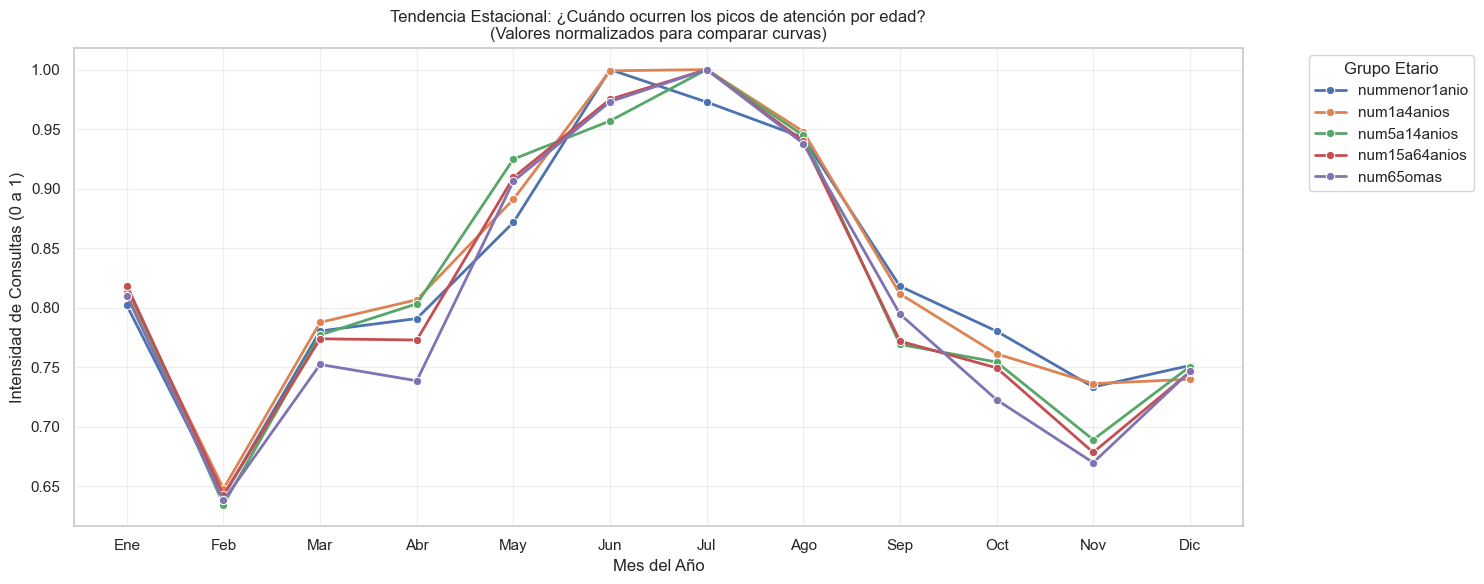


[7] ANALIZANDO COSTOS UNITARIOS POR ESTABLECIMIENTO...


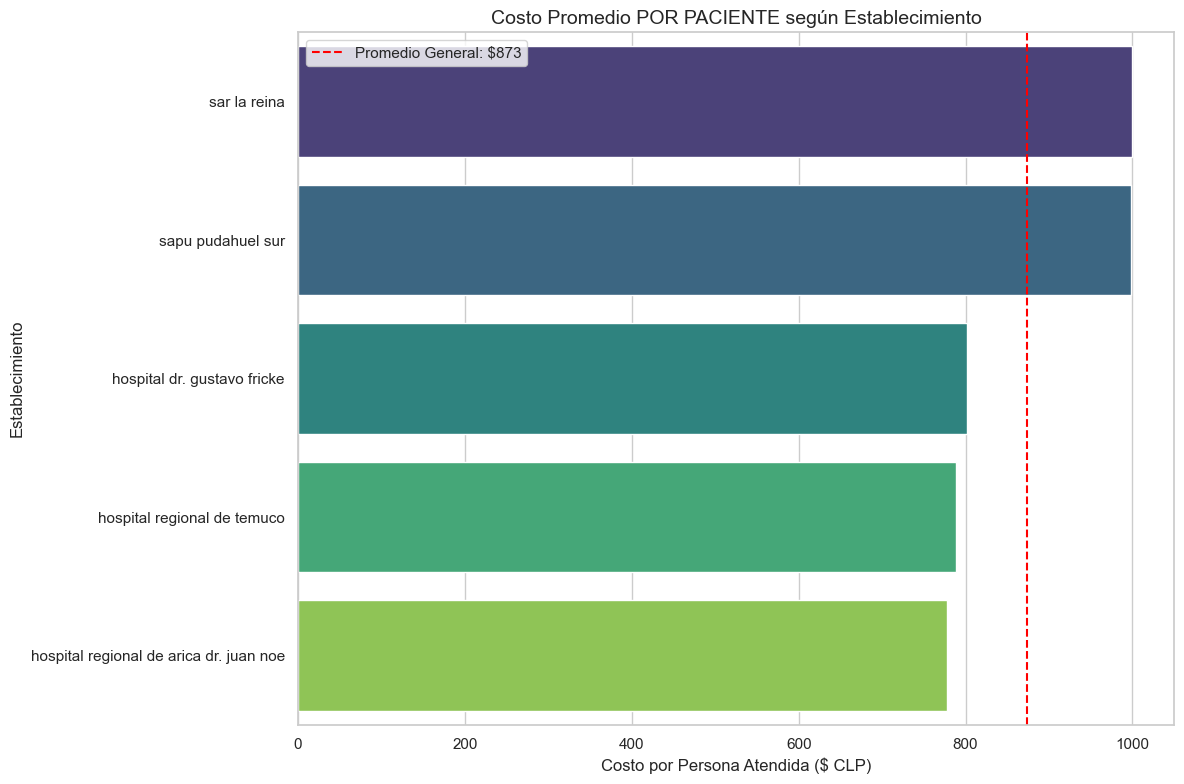


[9] ANALIZANDO COSTO PROMEDIO POR CAUSA...


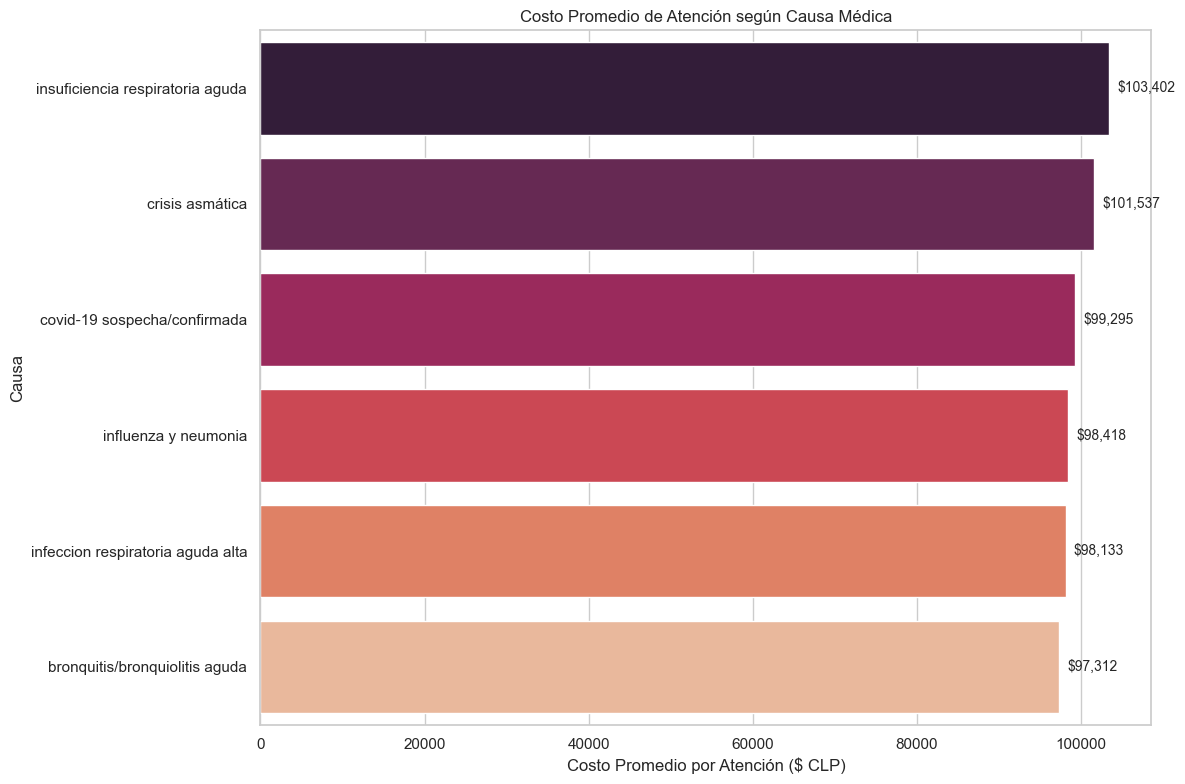


[12] ANALIZANDO COMPORTAMIENTO MENSUAL PROMEDIO...


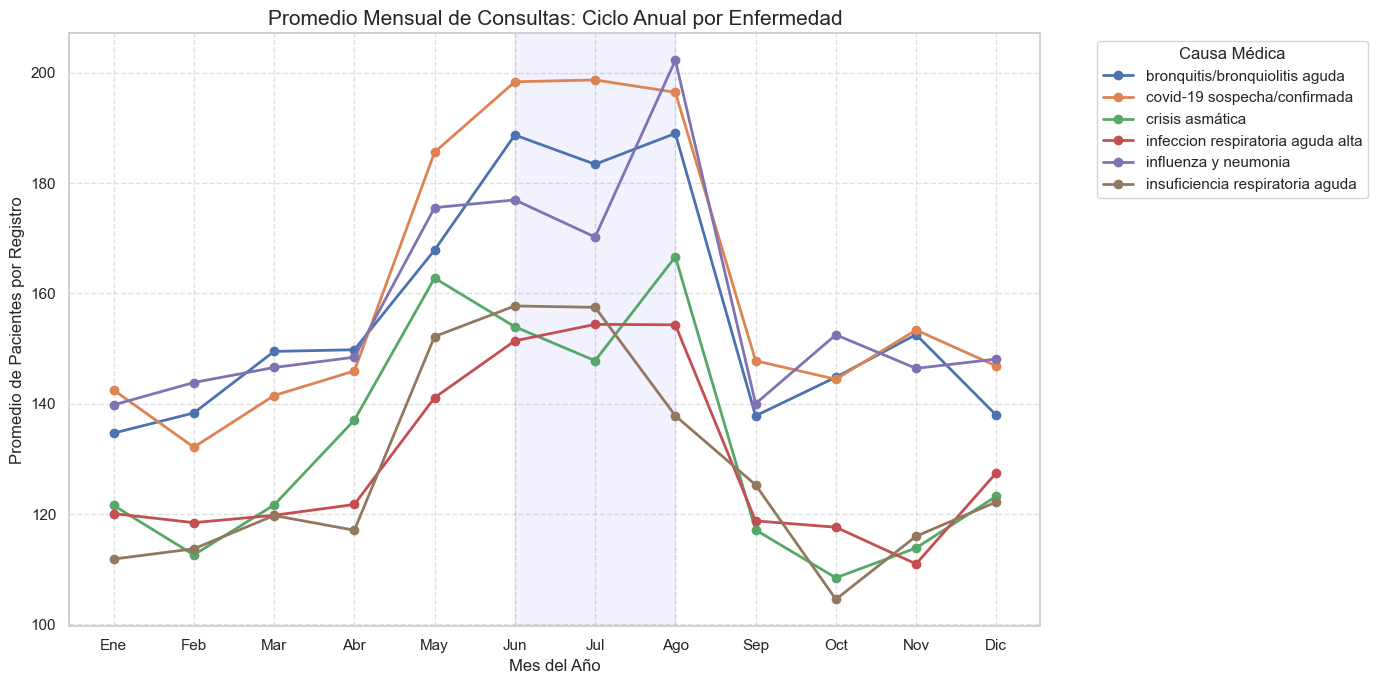

In [ ]:
#Análisis y Visualización
import src.analisis as analisis_module
import importlib
importlib.reload(analisis_module)


analisis_module.generar_informe_eda(df_limpio)